In [232]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
from scipy.optimize import curve_fit

In [233]:
df_1_7 = pd.read_csv("output/default.csv")
df_0_5 = pd.read_csv("output/BField_0_5T.csv")
df_1_0 = pd.read_csv("output/BField_1_0T.csv")
df_2_5 = pd.read_csv("output/BField_2_5T.csv")

In [234]:
def gaussian(x, A, x_0, sigma):
    return A * np.exp(-(x - x_0)**2 / (2 * sigma**2))

def gaussian_sigma(data):
    sigma_guess = (np.percentile(data, 84) - np.percentile(data, 16)) / 2

    mean = data.mean() 
    counts, edges = np.histogram(data, bins=50, range=(mean - 2 * sigma_guess, mean + 2 * sigma_guess))
    mids = (edges[:-1] + edges[1:]) / 2

    popt, _ = curve_fit(gaussian, mids, counts, p0=[max(counts), mids[np.argmax(counts)], sigma_guess])
    return abs(popt[2]) 

RuntimeError: Optimal parameters not found: Number of calls to function has reached maxfev = 800.

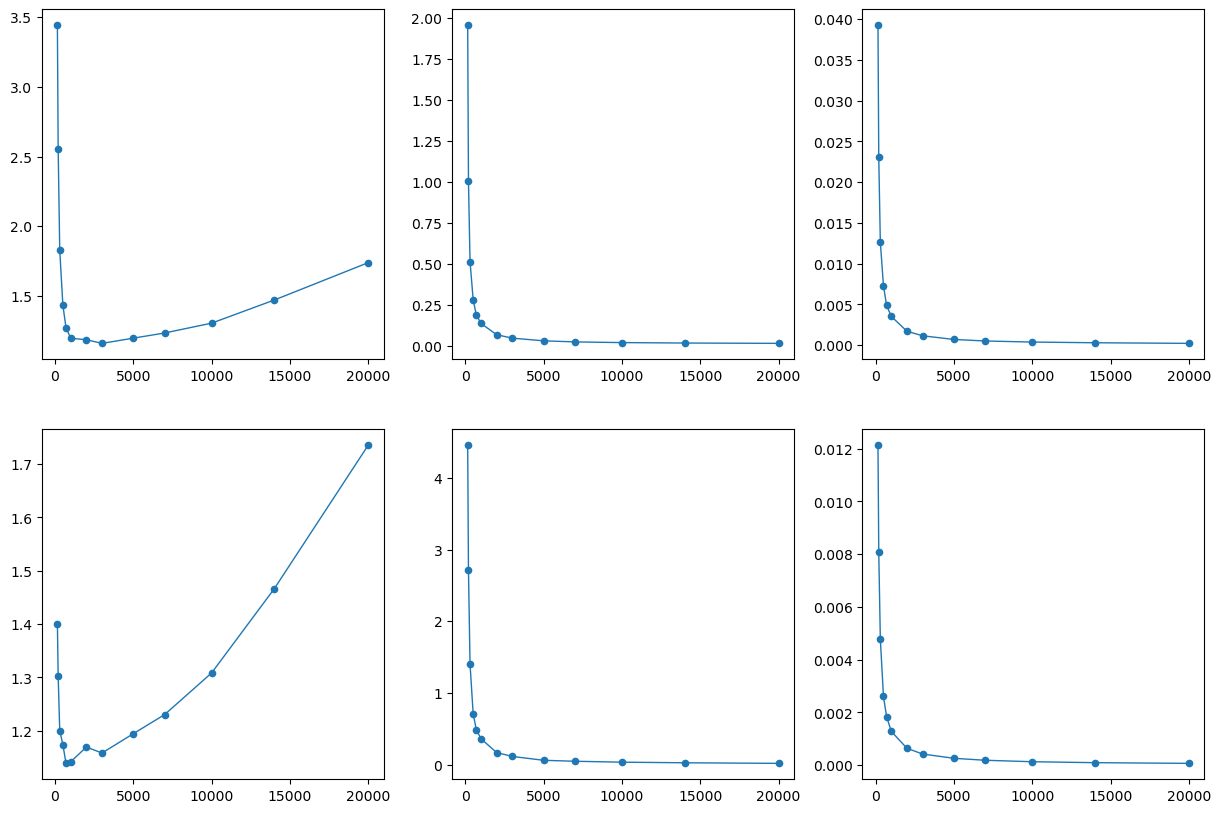

In [277]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

eta_bins = [
    (-3.0, -1.0),
    (-1.0,  1.0),
    ( 1.0,  3.0),
]

for eta_lo, eta_hi in eta_bins:
    df_eta = df_1_7[(df_1_7["eta"] >= eta_lo) & (df_1_7["eta"] < eta_hi)]
    momentum_points = sorted(df_eta["True p"].unique())[1:]

    p_GeV = []
    sigma_delta_pT = []
    sigma_delta_p = []
    sigma_delta_d0 = []
    sigma_delta_z0 = []
    sigma_delta_phi0 = []
    sigma_delta_theta = []

    for p in momentum_points:
        subset = df_eta[df_eta["True p"] == p]

        true_pT = np.sqrt(subset["True pX"]**2 + subset["True pY"]**2)
        fit_p = subset["Fit pT"] * np.sqrt(1.0 + subset["Fit tanl"]**2)

        pT_residual = (subset["Fit pT"] - true_pT) / true_pT
        p_residual  = (fit_p - subset["True p"]) / subset["True p"]

        true_phi0 = np.arctan2(subset["True pY"], subset["True pX"])
        phi_diff = (subset["Fit phi0"] - np.arctan2(subset["True pY"], subset["True pX"])) 
        phi0_residual = np.arctan2(np.cos(phi_diff), np.sin(phi_diff))

        theta_true = np.arctan2(true_pT, subset["True pZ"])
        theta_fit  = np.arctan2(1.0, subset["Fit tanl"])
        theta_residual = theta_fit - theta_true

        sigma_delta_pT.append(100.0 * gaussian_sigma(pT_residual))      
        sigma_delta_p.append(100.0 * gaussian_sigma(p_residual))        
        sigma_delta_d0.append(gaussian_sigma(subset["Fit d0"]))         
        sigma_delta_z0.append(gaussian_sigma(subset["Fit z0"]))         
        sigma_delta_phi0.append(gaussian_sigma(phi0_residual))    
        sigma_delta_theta.append(gaussian_sigma(theta_residual))  

    label = fr"${eta_lo} < \eta < {eta_hi}$"

    axes[0, 0].plot(momentum_points, sigma_delta_pT, marker="o", ms=4.5, lw=1.0, label=label)
    axes[1, 0].plot(momentum_points, sigma_delta_p,  marker="o", ms=4.5, lw=1.0, label=label)
    axes[0, 1].plot(momentum_points, sigma_delta_d0, marker="o", ms=4.5, lw=1.0, label=label)
    axes[1, 1].plot(momentum_points, sigma_delta_z0, marker="o", ms=4.5, lw=1.0, label=label)
    axes[0, 2].plot(momentum_points, sigma_delta_phi0, marker="o", ms=4.5, lw=1.0, label=label)
    axes[1, 2].plot(momentum_points, sigma_delta_theta, marker="o", ms=4.5, lw=1.0, label=label)

title_fs = 16
label_fs = 12
tick_fs = 11
legend_fs = 12

# Titles
axes[0, 0].set_title(r"$p_T$ resolution", fontsize=title_fs)
axes[1, 0].set_title(r"$p$ resolution", fontsize=title_fs)
axes[0, 1].set_title(r"$d_0$ resolution", fontsize=title_fs)
axes[1, 1].set_title(r"$z_0$ resolution", fontsize=title_fs)
axes[0, 2].set_title(r"$\phi_0$ resolution", fontsize=title_fs)
axes[1, 2].set_title(r"$\theta$ resolution", fontsize=title_fs)

# Y labels
axes[0, 0].set_ylabel(r"$\sigma(\Delta p_T / p_T)$ [%]", fontsize=label_fs)
axes[1, 0].set_ylabel(r"$\sigma(\Delta p / p)$ [%]", fontsize=label_fs)
axes[0, 1].set_ylabel(r"$\sigma(d_0)$ [mm]", fontsize=label_fs)
axes[1, 1].set_ylabel(r"$\sigma(z_0)$ [mm]", fontsize=label_fs)
axes[0, 2].set_ylabel(r"$\sigma(\phi_0)$ [rad]", fontsize=label_fs)
axes[1, 2].set_ylabel(r"$\sigma(\theta)$ [rad]", fontsize=label_fs)

# X labels
for ax in axes.flat:
    ax.set_xlabel(r"Momentum [MeV]", fontsize=label_fs)
    ax.set_xscale("log")
    ax.grid(True, which="major", alpha=0.25)
    ax.grid(True, which="minor", axis="x", alpha=0.10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", labelsize=tick_fs)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.95),   
    ncol=3,
    frameon=True,
    fancybox=True,
    framealpha=1.0,
    edgecolor="0.8",
    fontsize=legend_fs,
    borderpad=0.6,
    labelspacing=0.6,
    handlelength=2.2,
)

plt.tight_layout(rect=(0, 0, 1, 0.90)) 
fig.subplots_adjust(hspace=0.32)
fig.subplots_adjust(wspace=0.3)
plt.show()

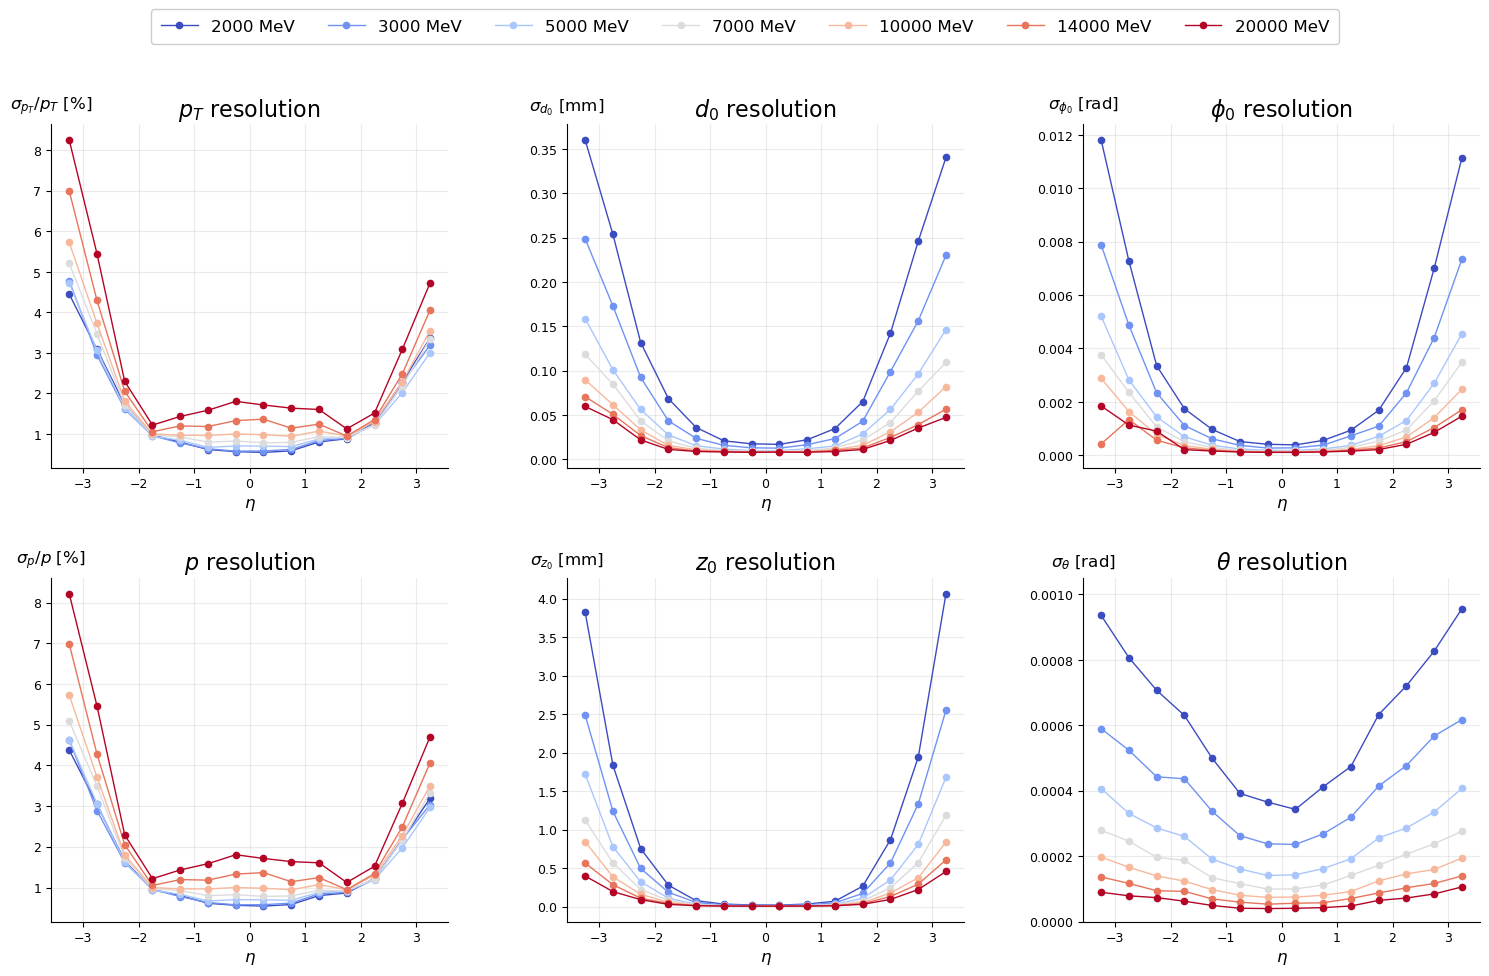

In [278]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

cmap = plt.colormaps['coolwarm']

momentum_points = sorted(df_1_7["True p"].unique())

for i, p in enumerate(momentum_points[-7::]):
    df_p = df_1_7[df_1_7["True p"] == p]

    etas = []
    sigma_delta_pT = []
    sigma_delta_p = []
    sigma_delta_d0 = []
    sigma_delta_z0 = []
    sigma_delta_phi0 = []
    sigma_delta_theta = []

    for eta_lo in np.arange(-3.5, 3.5, 0.5):
        eta_hi = eta_lo + 0.5
        subset = df_p[(df_p["eta"] >= eta_lo) &
                      (df_p["eta"] < eta_hi)]
        etas.append((eta_lo + eta_hi) / 2)

        true_pT = np.sqrt(subset["True pX"]**2 + subset["True pY"]**2)
        fit_p = subset["Fit pT"] * np.sqrt(1.0 + subset["Fit tanl"]**2)

        pT_residual = (subset["Fit pT"] - true_pT) / true_pT
        p_residual  = (fit_p - subset["True p"]) / subset["True p"]

        true_phi0 = np.arctan2(subset["True pY"], subset["True pX"])
        phi_diff = (subset["Fit phi0"] - np.arctan2(subset["True pY"], subset["True pX"])) 
        phi0_residual = np.arctan2(np.cos(phi_diff), np.sin(phi_diff))

        theta_true = np.arctan2(true_pT, subset["True pZ"])
        theta_fit  = np.arctan2(1.0, subset["Fit tanl"])
        theta_residual = theta_fit - theta_true

        sigma_delta_pT.append(100.0 * gaussian_sigma(pT_residual))      # percent
        sigma_delta_p.append(100.0 * gaussian_sigma(p_residual))        # percent
        sigma_delta_d0.append(gaussian_sigma(subset["Fit d0"]))         # mm
        sigma_delta_z0.append(gaussian_sigma(subset["Fit z0"]))         # mm
        sigma_delta_phi0.append(gaussian_sigma(phi0_residual))    # mrad
        sigma_delta_theta.append(gaussian_sigma(theta_residual))  # mrad

    label = f"{p} MeV"

    color = cmap(i / 6)
    axes[0, 0].plot(etas, sigma_delta_pT, marker="o", ms=4.5, lw=1.0, label=label, color=color)
    axes[1, 0].plot(etas, sigma_delta_p,  marker="o", ms=4.5, lw=1.0, label=label, color=color)
    axes[0, 1].plot(etas, sigma_delta_d0, marker="o", ms=4.5, lw=1.0, label=label, color=color)
    axes[1, 1].plot(etas, sigma_delta_z0, marker="o", ms=4.5, lw=1.0, label=label, color=color)
    axes[0, 2].plot(etas, sigma_delta_phi0, marker="o", ms=4.5, lw=1.0, label=label, color=color)
    axes[1, 2].plot(etas, sigma_delta_theta, marker="o", ms=4.5, lw=1.0, label=label, color=color)

title_fs = 16
label_fs = 12
tick_fs = 9
legend_fs = 12

# Titles
axes[0, 0].set_title(r"$p_T$ resolution", fontsize=title_fs)
axes[1, 0].set_title(r"$p$ resolution", fontsize=title_fs)
axes[0, 1].set_title(r"$d_0$ resolution", fontsize=title_fs)
axes[1, 1].set_title(r"$z_0$ resolution", fontsize=title_fs)
axes[0, 2].set_title(r"$\phi_0$ resolution", fontsize=title_fs)
axes[1, 2].set_title(r"$\theta$ resolution", fontsize=title_fs)

# Y labels
axes[0, 0].set_ylabel(r"$\sigma_{p_T} / p_T$ [%]", fontsize=label_fs, rotation=0, labelpad=20)
axes[1, 0].set_ylabel(r"$\sigma_{p} / p$ [%]", fontsize=label_fs, rotation=0, labelpad=20)
axes[0, 1].set_ylabel(r"$\sigma_{d_0}$ [mm]", fontsize=label_fs, rotation=0, labelpad=20)
axes[1, 1].set_ylabel(r"$\sigma_{z_0}$ [mm]", fontsize=label_fs, rotation=0, labelpad=20)
axes[0, 2].set_ylabel(r"$\sigma_{\phi_0}$ [rad]", fontsize=label_fs, rotation=0, labelpad=20)
axes[1, 2].set_ylabel(r"$\sigma_{\theta}$ [rad]", fontsize=label_fs, rotation=0, labelpad=20)

axes[1, 2].set_ylim(0, 0.00105)

# X labels
for ax in axes.flat:
    ax.set_xlabel(r"$\eta$", fontsize=label_fs)
    ax.grid(True, which="major", alpha=0.25)
    ax.grid(True, which="minor", axis="x", alpha=0.10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", labelsize=tick_fs)
    ax.yaxis.set_label_coords(0.0, 1.02)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.98),   
    ncol=7,
    frameon=True,
    fancybox=True,
    framealpha=1.0,
    edgecolor="0.8",
    fontsize=legend_fs,
    borderpad=0.6,
    labelspacing=0.6,
    handlelength=2.2,
)

plt.tight_layout(rect=(0, 0, 1, 0.90)) 
fig.subplots_adjust(hspace=0.32)
fig.subplots_adjust(wspace=0.3)
plt.show()

In [237]:
for i in sorted(df_1_7["Number of Hits"].unique()):
    print(i, len(df_1_7[df_1_7["Number of Hits"] == i].index))

KeyError: 'Number of Hits'

KeyError: 'Number of Hits'

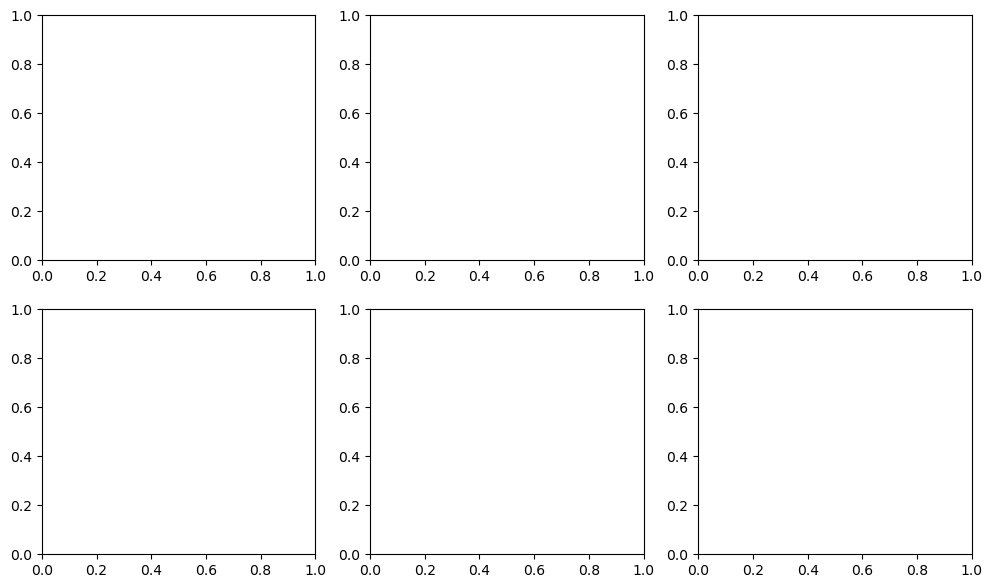

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7))

eta_bins = [
    (-2.5, -1.0),
    (-1.0,  1.0),
    ( 1.0,  2.5),
]

for numHits in range(4, 8):
    df = df_1_7[df_1_7["Number of Hits"] == numHits]
    for i, (eta_lo, eta_hi) in enumerate(eta_bins):
        df_eta = df[(df["Pseudorapidity"] >= eta_lo) &
                    (df["Pseudorapidity"] < eta_hi)]
        
        momentum_points = sorted(df_eta["True Momentum (MeV/c)"].unique())
        p_GeV = []
        sigma_delta_pT = []
        mean_DCA = []

        for p in momentum_points[:]:
            subset = df_eta[df_eta["True Momentum (MeV/c)"] == p]
            if (len(subset.index) < 20):
                continue
            p_GeV.append(p / 1000)

            pT_residual = (subset["Fitted Transverse Momentum (MeV/c)"] - subset["True Transverse Momentum (MeV/c)"]) / subset["True Transverse Momentum (MeV/c)"]
            sigma_guess = (np.percentile(pT_residual, 84) - np.percentile(pT_residual, 16)) / 2
            
            mean = pT_residual.mean() 
            counts, edges = np.histogram(pT_residual, bins=50, range=(mean - 1.5 * sigma_guess, mean + 1.5 * sigma_guess))
            mids = (edges[:-1] + edges[1:]) / 2

            print(numHits, p, i)
            popt, _ = curve_fit(gaussian, mids, counts, p0=[max(counts), mids[np.argmax(counts)], sigma_guess])
            sigma_delta_pT.append(abs(popt[2]))        

            mean_DCA.append(subset["DCA (mm)"].mean())


        axes[0, i].plot(p_GeV, np.array(sigma_delta_pT) * 100, marker="o", label=f"{numHits} hits")
        axes[0, i].set_title(f"{eta_lo} < η < {eta_hi}")
        axes[0, i].set_xlabel("Momentum (GeV)")
        axes[0, i].set_ylabel("δp/p (%)")
        axes[0, i].grid(alpha=0.3)

        axes[1, i].plot(p_GeV, mean_DCA, marker="o", label=f"{numHits} hits")
        axes[1, i].set_title(f"{eta_lo} < η < {eta_hi}")
        axes[1, i].set_xlabel("Momentum (GeV)")
        axes[1, i].set_ylabel("DCA (mm)")
        axes[1, i].grid(alpha=0.3)
        axes[1, i].set_ylim(0, 0.2)

for i in range(3):
    axes[0, i].legend()

plt.suptitle("Track parameters for different values of magnetic field")
plt.tight_layout()
plt.show()

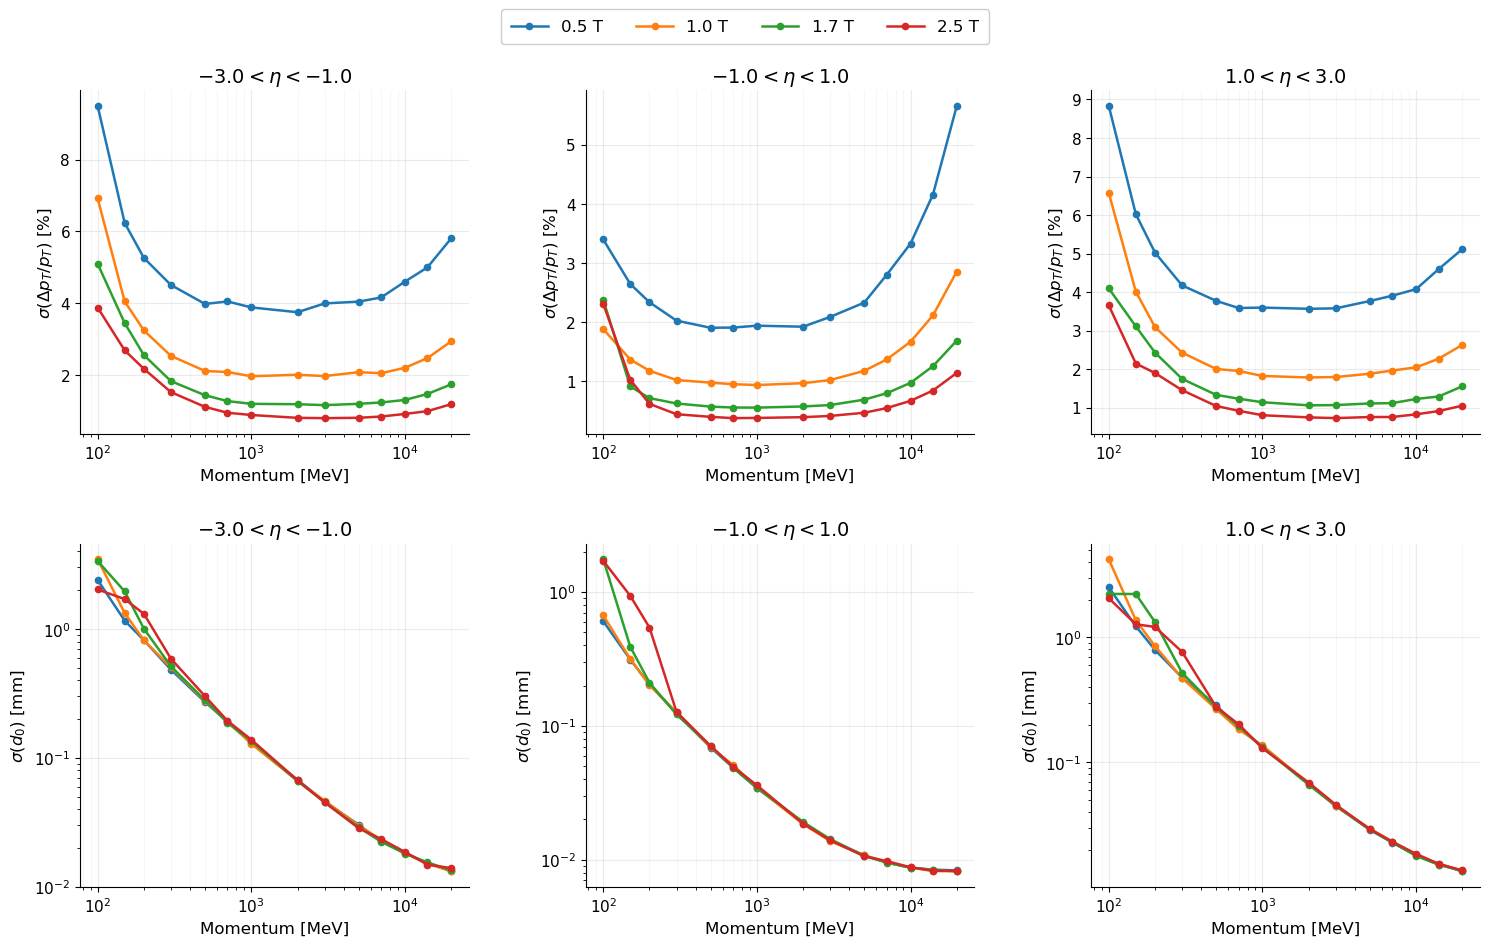

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

eta_bins = [
    (-3.0, -1.0),
    (-1.0,  1.0),
    ( 1.0,  3.0),
]

dataframes = {0.5: df_0_5, 1.0: df_1_0, 1.7: df_1_7, 2.5: df_2_5}

title_fs = 14
label_fs = 12
tick_fs = 11
legend_fs = 12

for B, df in dataframes.items():
    for i, (eta_lo, eta_hi) in enumerate(eta_bins):
        df_eta = df[(df["eta"] >= eta_lo) & (df["eta"] < eta_hi)]
        momentum_points = sorted(df_eta["True p"].unique())

        p_GeV = []
        sigma_delta_pT = []
        sigma_delta_d0 = []

        for p in momentum_points:
            subset = df_eta[df_eta["True p"] == p]

            true_pT = np.sqrt(subset["True pX"]**2 + subset["True pY"]**2)

            pT_residual = (subset["Fit pT"] - true_pT) / true_pT

            sigma_delta_pT.append(100.0 * gaussian_sigma(pT_residual))
            sigma_delta_d0.append(gaussian_sigma(subset["Fit d0"]))

        label = fr"{B} T"
        
        axes[0, i].plot(momentum_points, sigma_delta_pT, marker="o", ms=4.5, lw=1.0, label=label)
        axes[1, i].plot(momentum_points, sigma_delta_d0, marker="o", ms=4.5, lw=1.0, label=label)

        axes[0, i].set_title(f"${eta_lo} < \eta < {eta_hi}$", fontsize=title_fs)
        axes[1, i].set_title(f"${eta_lo} < \eta < {eta_hi}$", fontsize=title_fs)

        axes[0, i].set_ylabel(r"$\sigma(\Delta p_T / p_T)$ [%]", fontsize=label_fs)
        axes[1, i].set_ylabel(r"$\sigma(d_0)$ [mm]", fontsize=label_fs)

        axes[1, i].set_yscale("log")

for ax in axes.flat:
    ax.set_xlabel(r"Momentum [MeV]", fontsize=label_fs)
    ax.set_xscale("log")
    ax.grid(True, which="major", alpha=0.25)
    ax.grid(True, which="minor", axis="x", alpha=0.10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", labelsize=tick_fs)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.95),   
    ncol=4,
    frameon=True,
    fancybox=True,
    framealpha=1.0,
    edgecolor="0.8",
    fontsize=legend_fs,
    borderpad=0.6,
    labelspacing=0.6,
    handlelength=2.2,
)

plt.tight_layout(rect=(0, 0, 1, 0.90)) 
fig.subplots_adjust(hspace=0.32)
fig.subplots_adjust(wspace=0.3)
plt.show()

In [240]:
df_7um = pd.read_csv("output/default.csv")
df_3um = pd.read_csv("output/resolution_3um.csv")
df_15um = pd.read_csv("output/resolution_15um.csv")
df_25um = pd.read_csv("output/resolution_25um.csv")

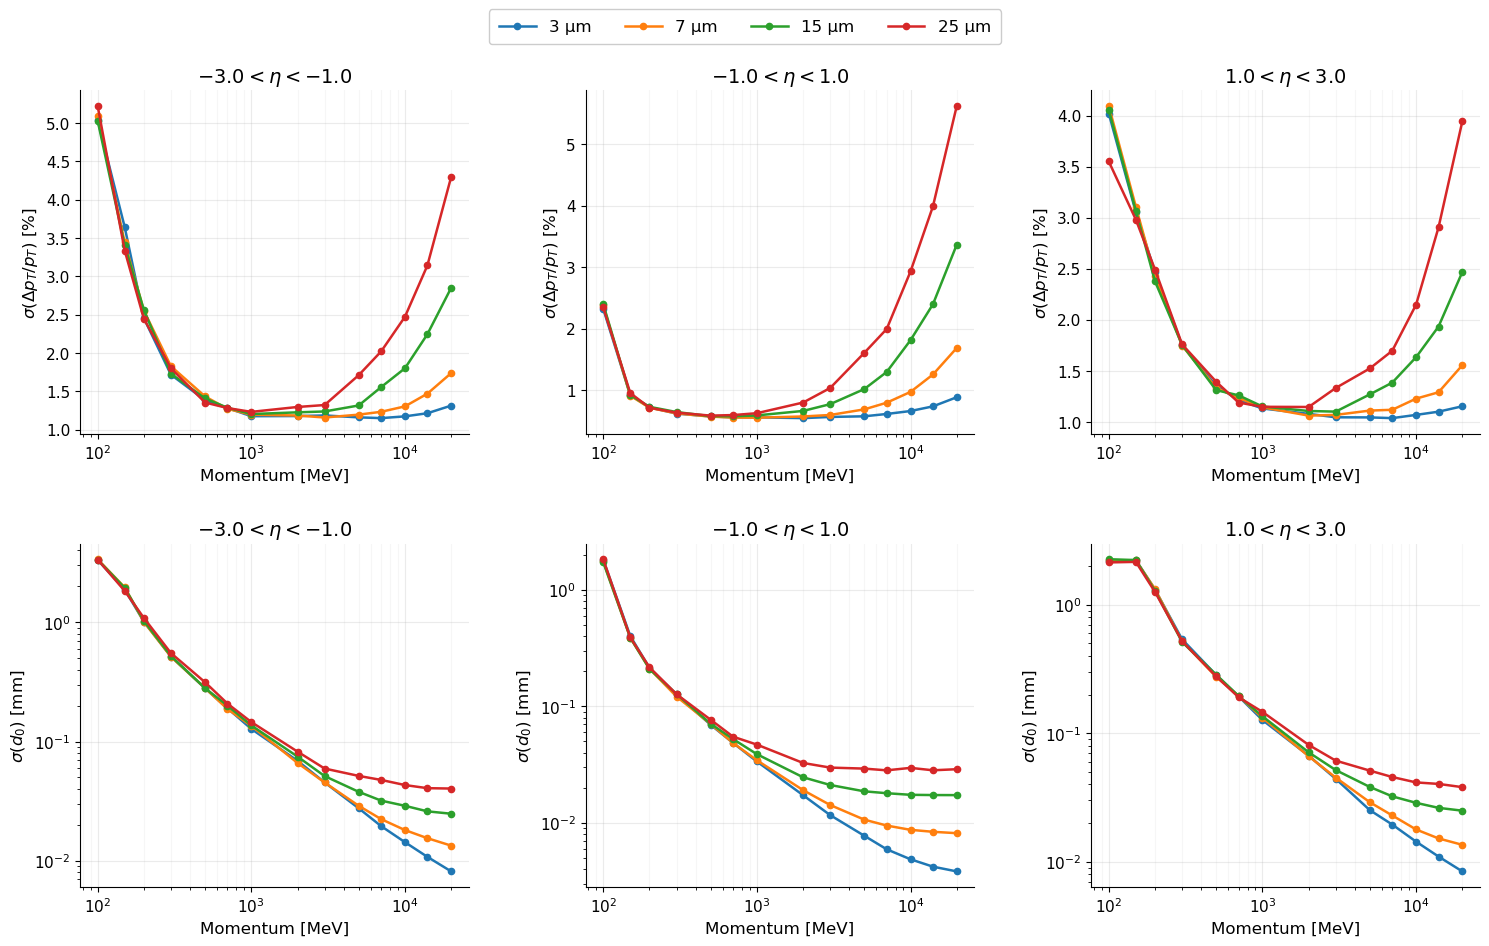

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

eta_bins = [
    (-3.0, -1.0),
    (-1.0,  1.0),
    ( 1.0,  3.0),
]

dataframes = {3: df_3um, 7: df_7um, 15: df_15um, 25: df_25um}

title_fs = 14
label_fs = 12
tick_fs = 11
legend_fs = 12

for resolution, df in dataframes.items():
    for i, (eta_lo, eta_hi) in enumerate(eta_bins):
        df_eta = df[(df["eta"] >= eta_lo) & (df["eta"] < eta_hi)]
        momentum_points = sorted(df_eta["True p"].unique())

        p_GeV = []
        sigma_delta_pT = []
        sigma_delta_d0 = []

        for p in momentum_points:
            subset = df_eta[df_eta["True p"] == p]

            true_pT = np.sqrt(subset["True pX"]**2 + subset["True pY"]**2)

            pT_residual = (subset["Fit pT"] - true_pT) / true_pT

            sigma_delta_pT.append(100.0 * gaussian_sigma(pT_residual))
            sigma_delta_d0.append(gaussian_sigma(subset["Fit d0"]))

        label = fr"{resolution} μm"

        axes[0, i].plot(momentum_points, sigma_delta_pT, marker="o", ms=4.5, lw=1.0, label=label)
        axes[1, i].plot(momentum_points, sigma_delta_d0, marker="o", ms=4.5, lw=1.0, label=label)

        axes[0, i].set_title(f"${eta_lo} < \eta < {eta_hi}$", fontsize=title_fs)
        axes[1, i].set_title(f"${eta_lo} < \eta < {eta_hi}$", fontsize=title_fs)

        axes[0, i].set_ylabel(r"$\sigma(\Delta p_T / p_T)$ [%]", fontsize=label_fs)
        axes[1, i].set_ylabel(r"$\sigma(d_0)$ [mm]", fontsize=label_fs)

        axes[0, i].set_xscale("log")
        axes[1, i].set_xscale("log")
        axes[1, i].set_yscale("log")


for ax in axes.flat:
    ax.set_xlabel(r"Momentum [MeV]", fontsize=label_fs)
    ax.grid(True, which="major", alpha=0.25)
    ax.grid(True, which="minor", axis="x", alpha=0.10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", labelsize=tick_fs)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.95),   
    ncol=4,
    frameon=True,
    fancybox=True,
    framealpha=1.0,
    edgecolor="0.8",
    fontsize=legend_fs,
    borderpad=0.6,
    labelspacing=0.6,
    handlelength=2.2,
)

plt.tight_layout(rect=(0, 0, 1, 0.90)) 
fig.subplots_adjust(hspace=0.32)
fig.subplots_adjust(wspace=0.3)
plt.show()

In [242]:
df_mat_x1 = pd.read_csv("output/default.csv")
df_mat_x2 = pd.read_csv("output/material_x2.csv")
df_mat_x3 = pd.read_csv("output/material_x3.csv")
df_mat_x4 = pd.read_csv("output/material_x4.csv")

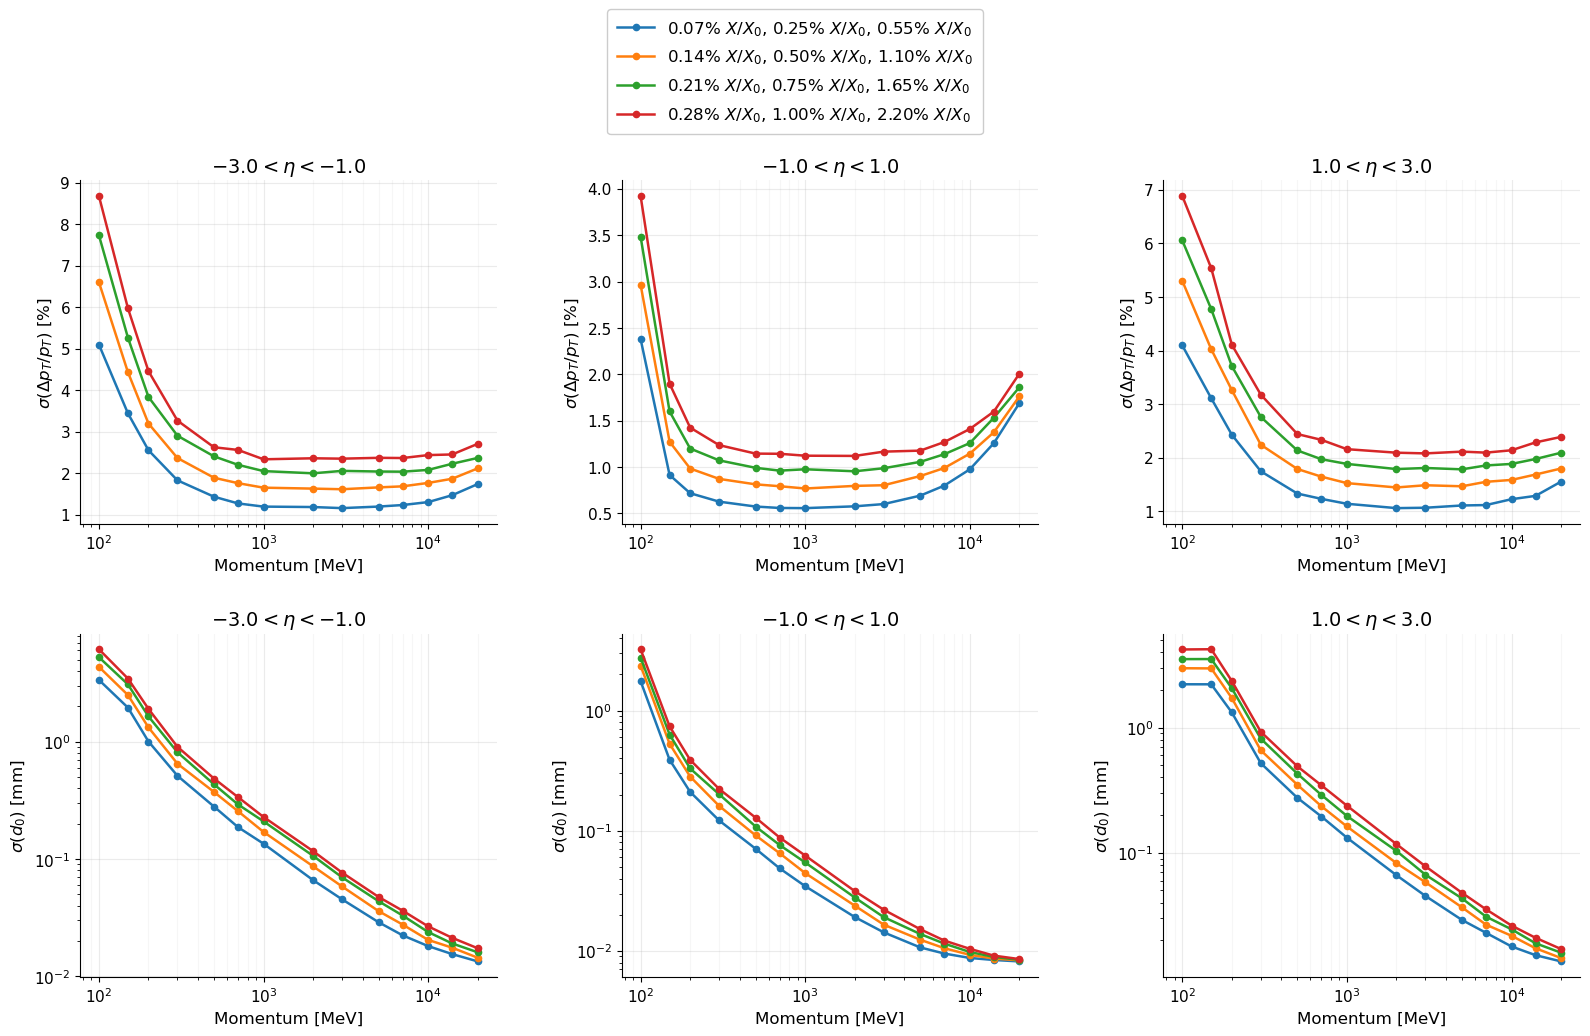

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

eta_bins = [
    (-3.0, -1.0),
    (-1.0,  1.0),
    ( 1.0,  3.0),
]

dataframes = {1: df_mat_x1, 2: df_mat_x2, 3: df_mat_x3, 4: df_mat_x4}
labels = {
    1: r"0.07% $X/X_0$, 0.25% $X/X_0$, 0.55% $X/X_0$",
    2: r"0.14% $X/X_0$, 0.50% $X/X_0$, 1.10% $X/X_0$",
    3: r"0.21% $X/X_0$, 0.75% $X/X_0$, 1.65% $X/X_0$",
    4: r"0.28% $X/X_0$, 1.00% $X/X_0$, 2.20% $X/X_0$"
}

title_fs = 14
label_fs = 12
tick_fs = 11
legend_fs = 12

for width, df in dataframes.items():
    for i, (eta_lo, eta_hi) in enumerate(eta_bins):
        df_eta = df[(df["eta"] >= eta_lo) & (df["eta"] < eta_hi)]
        momentum_points = sorted(df_eta["True p"].unique())

        p_GeV = []
        sigma_delta_pT = []
        sigma_delta_d0 = []

        for p in momentum_points:
            subset = df_eta[df_eta["True p"] == p]

            true_pT = np.sqrt(subset["True pX"]**2 + subset["True pY"]**2)

            pT_residual = (subset["Fit pT"] - true_pT) / true_pT

            sigma_delta_pT.append(100.0 * gaussian_sigma(pT_residual))
            sigma_delta_d0.append(gaussian_sigma(subset["Fit d0"]))

        label = labels[width]

        axes[0, i].plot(momentum_points, sigma_delta_pT, marker="o", ms=4.5, lw=1.0, label=label)
        axes[1, i].plot(momentum_points, sigma_delta_d0, marker="o", ms=4.5, lw=1.0, label=label)

        axes[0, i].set_title(f"${eta_lo} < \eta < {eta_hi}$", fontsize=title_fs)
        axes[1, i].set_title(f"${eta_lo} < \eta < {eta_hi}$", fontsize=title_fs)

        axes[0, i].set_ylabel(r"$\sigma(\Delta p_T / p_T)$ [%]", fontsize=label_fs)
        axes[1, i].set_ylabel(r"$\sigma(d_0)$ [mm]", fontsize=label_fs)

        axes[0, i].set_xscale("log")
        axes[1, i].set_xscale("log")
        axes[1, i].set_yscale("log")


for ax in axes.flat:
    ax.set_xlabel(r"Momentum [MeV]", fontsize=label_fs)
    ax.grid(True, which="major", alpha=0.25)
    ax.grid(True, which="minor", axis="x", alpha=0.10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", labelsize=tick_fs)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.04),   
    ncol=1,
    frameon=True,
    fancybox=True,
    framealpha=1.0,
    edgecolor="0.8",
    fontsize=legend_fs,
    borderpad=0.6,
    labelspacing=0.6,
    handlelength=2.2,
)

plt.tight_layout(rect=(0, 0, 1, 0.90)) 
fig.subplots_adjust(hspace=0.32)
fig.subplots_adjust(wspace=0.3)
plt.show()

In [ ]:
df_pion = pd.read_csv("output/default.csv")
df_proton = pd.read_csv("output/gun_protons.csv")
df_kaon = pd.read_csv("output/gun_kaons.csv")
df_electron = pd.read_csv("output/gun_electrons.csv")

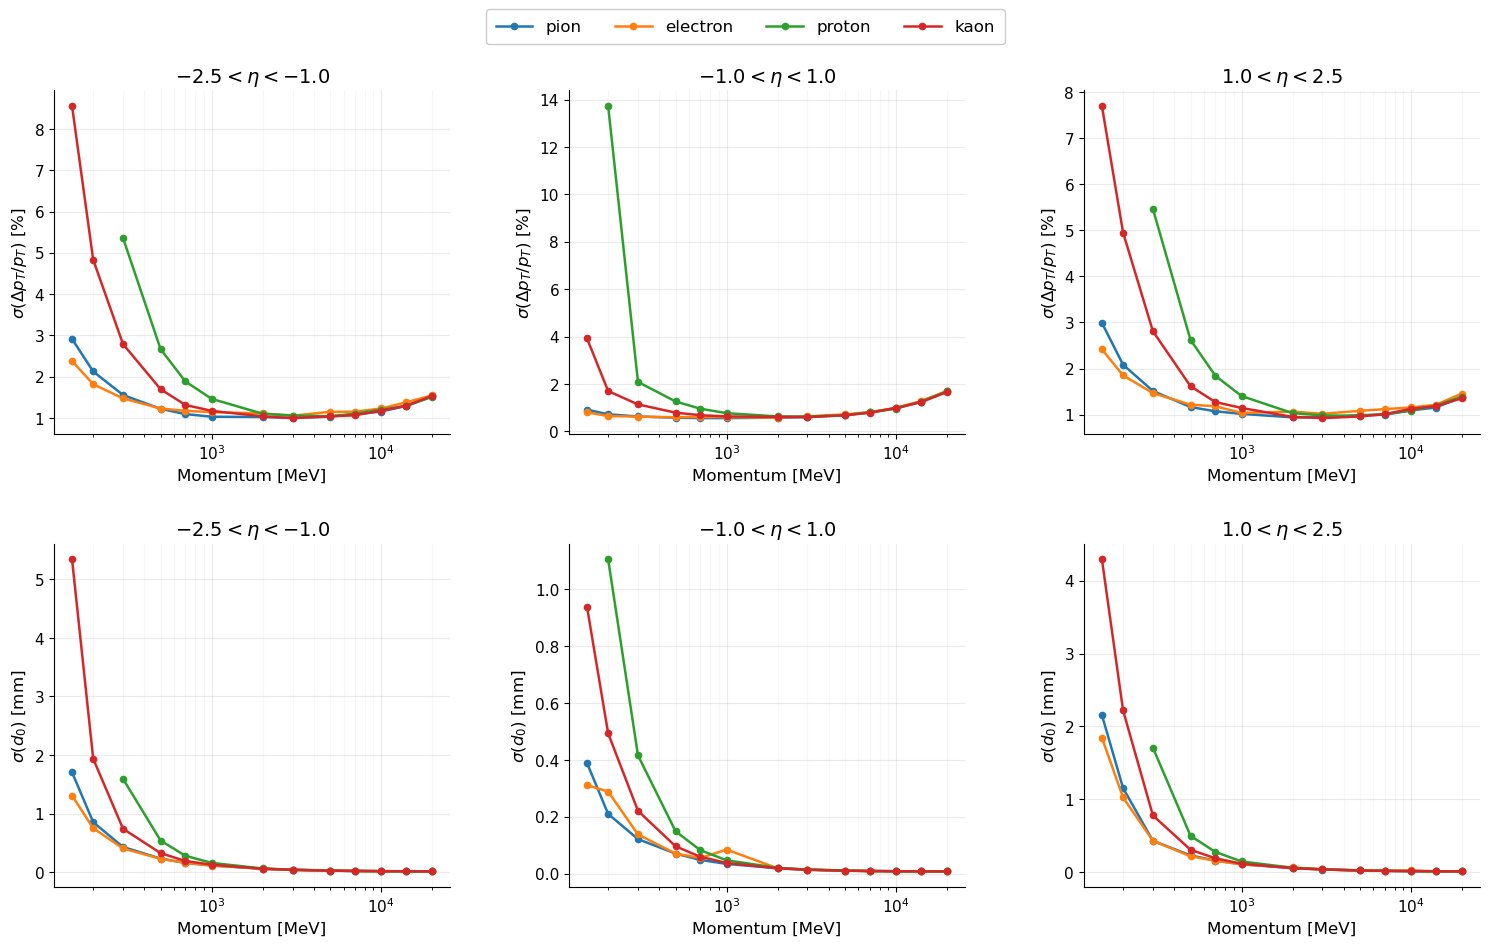

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

eta_bins = [
    (-2.5, -1.0),
    (-1.0,  1.0),
    ( 1.0,  2.5),
]

dataframes = {"pion": df_pion, "electron": df_electron, "proton": df_proton, "kaon": df_kaon}

title_fs = 14
label_fs = 12
tick_fs = 11
legend_fs = 12

for particle, df in dataframes.items():
    for i, (eta_lo, eta_hi) in enumerate(eta_bins):
        df_eta = df[(df["eta"] >= eta_lo) & (df["eta"] < eta_hi)]
        momentum_points = sorted(df_eta["True p"].unique())[1:]

        p_GeV = []
        sigma_delta_pT = []
        sigma_delta_d0 = []

        for p in momentum_points:
            subset = df_eta[df_eta["True p"] == p]

            true_pT = np.sqrt(subset["True pX"]**2 + subset["True pY"]**2)

            pT_residual = (subset["Fit pT"] - true_pT) / true_pT

            sigma_delta_pT.append(100.0 * gaussian_sigma(pT_residual))
            sigma_delta_d0.append(gaussian_sigma(subset["Fit d0"]))

        label = particle

        axes[0, i].plot(momentum_points, sigma_delta_pT, marker="o", ms=4.5, lw=1.0, label=label)
        axes[1, i].plot(momentum_points, sigma_delta_d0, marker="o", ms=4.5, lw=1.0, label=label)

        axes[0, i].set_title(f"${eta_lo} < \eta < {eta_hi}$", fontsize=title_fs)
        axes[1, i].set_title(f"${eta_lo} < \eta < {eta_hi}$", fontsize=title_fs)

        axes[0, i].set_ylabel(r"$\sigma(\Delta p_T / p_T)$ [%]", fontsize=label_fs)
        axes[1, i].set_ylabel(r"$\sigma(d_0)$ [mm]", fontsize=label_fs)

        axes[0, i].set_xscale("log")
        axes[1, i].set_xscale("log")


for ax in axes.flat:
    ax.set_xlabel(r"Momentum [MeV]", fontsize=label_fs)
    ax.grid(True, which="major", alpha=0.25)
    ax.grid(True, which="minor", axis="x", alpha=0.10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", labelsize=tick_fs)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.95),   
    ncol=4,
    frameon=True,
    fancybox=True,
    framealpha=1.0,
    edgecolor="0.8",
    fontsize=legend_fs,
    borderpad=0.6,
    labelspacing=0.6,
    handlelength=2.2,
)

plt.tight_layout(rect=(0, 0, 1, 0.90)) 
fig.subplots_adjust(hspace=0.32)
fig.subplots_adjust(wspace=0.3)
plt.show()